<a href="https://colab.research.google.com/github/RyanSVargas/Quant-Finance-Research/blob/main/03_Risk_Parity_Engine/Risk_Parity_Portfolio_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Assets: US Market, Aussie Market, Gold, Bitcoin, Bonds
tickers = ["SPY", "VAS.AX", "GLD", "BTC-USD", "TLT"]
data = yf.download(tickers, start="2024-01-01", end="2026-02-08")['Close'].ffill()

# 2. Calculate Returns and Volatility
returns = data.pct_change().dropna()
vol = returns.std() * np.sqrt(252) # Annualized Vol

# 3. The Math: Weights are inversely proportional to risk
inv_vol = 1 / vol
weights = inv_vol / inv_vol.sum()

print("--- YOUR MATHEMATICAL ALLOCATION ---")
for ticker, weight in zip(tickers, weights):
    print(f"{ticker}: {weight:.2%}")

/tmp/ipython-input-3638029067.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2024-01-01", end="2026-02-08")['Close'].ffill()
[*********************100%***********************]  5 of 5 completed

--- YOUR MATHEMATICAL ALLOCATION ---
SPY: 6.87%
VAS.AX: 16.88%
GLD: 21.08%
BTC-USD: 26.43%
TLT: 28.75%


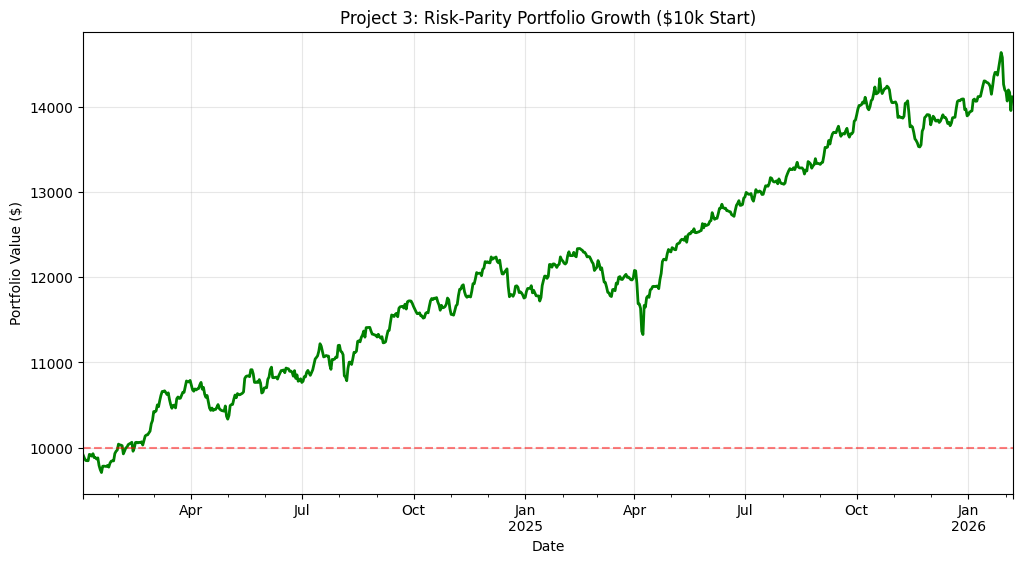

--- PORTFOLIO FINALE ---
Total Return: 40.99%
Final Value: $14,098.75


In [ ]:
# 1. Calculate Portfolio Returns
# We multiply each asset's daily return by its specific weight
portfolio_returns = (returns * weights).sum(axis=1)

# 2. Calculate Cumulative Growth of $10,000
initial_investment = 10000
growth = (1 + portfolio_returns).cumprod() * initial_investment

# 3. Plot the result
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
growth.plot(title="Project 3: Risk-Parity Portfolio Growth ($10k Start)", color='green', linewidth=2)
plt.axhline(y=10000, color='red', linestyle='--', alpha=0.5) # The "Break Even" line
plt.ylabel("Portfolio Value ($)")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Final Audit
total_return = (growth.iloc[-1] - initial_investment) / initial_investment
print(f"--- PORTFOLIO FINALE ---")
print(f"Total Return: {total_return:.2%}")
print(f"Final Value: ${growth.iloc[-1]:,.2f}")

In [ ]:
# Calculate the Daily Sharpe Ratio for the Portfolio
# (Mean Daily Return / Std Dev of Daily Returns) * sqrt(252)
mean_ret = portfolio_returns.mean()
std_ret = portfolio_returns.std()
sharpe_ratio = (mean_ret / std_ret) * np.sqrt(252)

print(f"--- PROJECT 3 RISK AUDIT ---")
print(f"Portfolio Sharpe Ratio: {sharpe_ratio:.2f}")

# Re-print your Max Drawdown with the 'iloc' fix to be clean
running_max = growth.cummax()
drawdown = (growth - running_max) / running_max
print(f"Portfolio Max Drawdown: {drawdown.iloc[-1]:.2%}")

--- PROJECT 3 RISK AUDIT ---
Portfolio Sharpe Ratio: 1.61
Portfolio Max Drawdown: -3.66%
